# Members:
- Aman Arora
- Alexandra Romanova
- Erion Vathi
- Lenny Blieffert
- Laura Pérez

### Group Project - London Bike Rentals

In this project, you will work with the London Bikes dataset, which records daily bike rentals in the city along with key variables such as dates, weather conditions, and seasonality.

The goal is to apply the full data analytics workflow:

- Clean and prepare the dataset.

- Explore the data through visualisation.

- Construct and interpret confidence intervals.

- Build a regression model to explain variation in bike rentals.

- By the end, you will connect statistical concepts with practical Python analysis.

In [13]:
## Import libraries and data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

bikes = pd.read_csv('../Data/london_bikes.csv')
bikes.head()


,date,bikes_hired,year,wday,month,week,cloud_cover,humidity,pressure,radiation,precipitation,snow_depth,sunshine,mean_temp,min_temp,max_temp,weekend
0,2010-07-30T00:00:00Z,6897,2010,Fri,Jul,30,6.0,65.0,10147.0,157.0,22.0,NaN,31.0,17.7,12.3,25.1,False
1,2010-07-31T00:00:00Z,5564,2010,Sat,Jul,30,5.0,70.0,10116.0,184.0,0.0,NaN,47.0,21.1,17.0,23.9,True
2,2010-08-01T00:00:00Z,4303,2010,Sun,Aug,30,7.0,63.0,10132.0,89.0,0.0,NaN,3.0,19.3,14.6,23.4,True
3,2010-08-02T00:00:00Z,6642,2010,Mon,Aug,31,7.0,59.0,10168.0,134.0,0.0,NaN,20.0,19.5,15.6,23.6,False
4,2010-08-03T00:00:00Z,7966,2010,Tue,Aug,31,5.0,66.0,10157.0,169.0,0.0,NaN,39.0,17.9,12.1,20.1,False


In [14]:
bikes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4934 entries, 0 to 4933
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4934 non-null   object 
 1   bikes_hired    4934 non-null   int64  
 2   year           4934 non-null   int64  
 3   wday           4934 non-null   object 
 4   month          4934 non-null   object 
 5   week           4934 non-null   int64  
 6   cloud_cover    4901 non-null   float64
 7   humidity       4851 non-null   float64
 8   pressure       4903 non-null   float64
 9   radiation      4894 non-null   float64
 10  precipitation  4903 non-null   float64
 11  snow_depth     4632 non-null   float64
 12  sunshine       4903 non-null   float64
 13  mean_temp      4903 non-null   float64
 14  min_temp       4872 non-null   float64
 15  max_temp       4903 non-null   float64
 16  weekend        4934 non-null   bool   
dtypes: bool(1), float64(10), int64(3), object(3)
memory 

In [15]:
bikes.describe()

,bikes_hired,year,week,cloud_cover,humidity,pressure,radiation,precipitation,snow_depth,sunshine,mean_temp,min_temp,max_temp
count,4934.000000,4934.000000,4934.000000,4901.000000,4851.000000,4903.000000,4894.000000,4903.000000,4632.000000,4903.000000,4903.000000,4872.000000,4903.000000
mean,26448.565869,2016.823470,26.896230,4.917568,75.710369,10153.096879,118.182060,17.354477,0.015112,41.231695,12.051703,8.060714,16.056680
std,9677.635260,3.910234,15.157628,2.368445,11.234117,105.267258,89.453589,38.243881,0.234630,38.966050,5.721325,5.266205,6.613207
min,0.000000,2010.000000,1.000000,0.000000,33.000000,9668.000000,2.000000,0.000000,0.000000,0.000000,-4.100000,-9.400000,-1.200000
25%,19604.000000,2013.000000,14.000000,3.000000,68.000000,10091.000000,40.000000,0.000000,0.000000,5.000000,7.700000,4.200000,11.000000
50%,26129.000000,2017.000000,27.000000,5.000000,77.000000,10162.000000,93.500000,0.000000,0.000000,32.000000,11.900000,8.250000,15.700000
75%,33233.750000,2020.000000,40.000000,7.000000,84.000000,10224.000000,186.000000,18.000000,0.000000,67.000000,16.600000,12.200000,21.000000
max,73094.000000,2024.000000,53.000000,9.000000,100.000000,10477.000000,402.000000,516.000000,7.000000,147.000000,30.900000,22.300000,40.200000


**1. Data Cleaning**

Check for missing values across columns. How would you handle them?

Inspect the date column and ensure it is correctly formatted as datetime. Extract useful features (year, month, day, day of week, season).

Convert categorical variables (e.g., season, weather) to appropriate categories in Python.

Ensure numeric columns (e.g., bikes rented, temperature) are in the right format.

A/ How would you handle them?

We would check if the proportion of mission values from each column is < 5%, if so, we drop the row, if between 5% and 30%, filling them with the mean and if greater than 30% consider dropping the whole column

In [16]:
# Data Cleaning
bikes.isnull().sum()
# Check if columns with null values are below or above 5%
bikes.isnull().mean() < 0.05
# Drop rows with null values as they are all below 5%
bikes = bikes.dropna()
bikes.isnull().sum()
bikes.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4570 entries, 88 to 4902
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4570 non-null   object 
 1   bikes_hired    4570 non-null   int64  
 2   year           4570 non-null   int64  
 3   wday           4570 non-null   object 
 4   month          4570 non-null   object 
 5   week           4570 non-null   int64  
 6   cloud_cover    4570 non-null   float64
 7   humidity       4570 non-null   float64
 8   pressure       4570 non-null   float64
 9   radiation      4570 non-null   float64
 10  precipitation  4570 non-null   float64
 11  snow_depth     4570 non-null   float64
 12  sunshine       4570 non-null   float64
 13  mean_temp      4570 non-null   float64
 14  min_temp       4570 non-null   float64
 15  max_temp       4570 non-null   float64
 16  weekend        4570 non-null   bool   
dtypes: bool(1), float64(10), int64(3), object(3)
memory usag

In [17]:
# Convert date column to datetime format
bikes['date'] = pd.to_datetime(bikes['date'])
# Extract year, month, day, and day of week from date column
bikes['year'] = bikes['date'].dt.year
bikes['month'] = bikes['date'].dt.month
bikes['day'] = bikes['date'].dt.day
bikes['day_of_week'] = bikes['date'].dt.dayofweek
# Create a new colum "season" based on the month
bikes['season'] = np.where(bikes['month'].isin([12, 1, 2]), 'Winter',
                           np.where(bikes['month'].isin([3, 4, 5]), 'Spring',
                                    np.where(bikes['month'].isin([6, 7, 8]), 'Summer', 'Fall')))
# Convert season column to categorical type
bikes['season'] = bikes['season'].astype('category')
# Convert day_of_week column to categorical type and map the values to the actual day names
bikes['day_of_week'] = bikes['day_of_week'].astype('category')
bikes['day_of_week'] = bikes['day_of_week'].map({0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
                                                 4: 'Friday', 5: 'Saturday', 6: 'Sunday'})
# Convert day_of_week column to categorical type
bikes['day_of_week'] = bikes['day_of_week'].astype('category')
# Month, wday and week as categorical
bikes['month'] = bikes['month'].astype('category')
bikes['year'] = bikes['year'].astype('category')
bikes['wday'] = bikes['day'].astype('category')
bikes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4570 entries, 88 to 4902
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   date           4570 non-null   datetime64[ns, UTC]
 1   bikes_hired    4570 non-null   int64              
 2   year           4570 non-null   category           
 3   wday           4570 non-null   category           
 4   month          4570 non-null   category           
 5   week           4570 non-null   int64              
 6   cloud_cover    4570 non-null   float64            
 7   humidity       4570 non-null   float64            
 8   pressure       4570 non-null   float64            
 9   radiation      4570 non-null   float64            
 10  precipitation  4570 non-null   float64            
 11  snow_depth     4570 non-null   float64            
 12  sunshine       4570 non-null   float64            
 13  mean_temp      4570 non-null   float64            
 

In [18]:
# Ensure numeric columns are in numeric format
for col in bikes.select_dtypes(include=['number']).columns.tolist():
    bikes[col] = pd.to_numeric(bikes[col], errors='coerce')

bikes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4570 entries, 88 to 4902
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   date           4570 non-null   datetime64[ns, UTC]
 1   bikes_hired    4570 non-null   int64              
 2   year           4570 non-null   category           
 3   wday           4570 non-null   category           
 4   month          4570 non-null   category           
 5   week           4570 non-null   int64              
 6   cloud_cover    4570 non-null   float64            
 7   humidity       4570 non-null   float64            
 8   pressure       4570 non-null   float64            
 9   radiation      4570 non-null   float64            
 10  precipitation  4570 non-null   float64            
 11  snow_depth     4570 non-null   float64            
 12  sunshine       4570 non-null   float64            
 13  mean_temp      4570 non-null   float64            
 

**2. Exploratory Data Analysis (EDA)**

Plot the distribution of bikes rented.

Explore how rentals vary by season and month.

Investigate the relationship between temperature and bikes rented.

**Deliverables:**

At least 3 clear visualisations with captions.

A short written interpretation of key patterns (seasonality, weather effects, etc.).



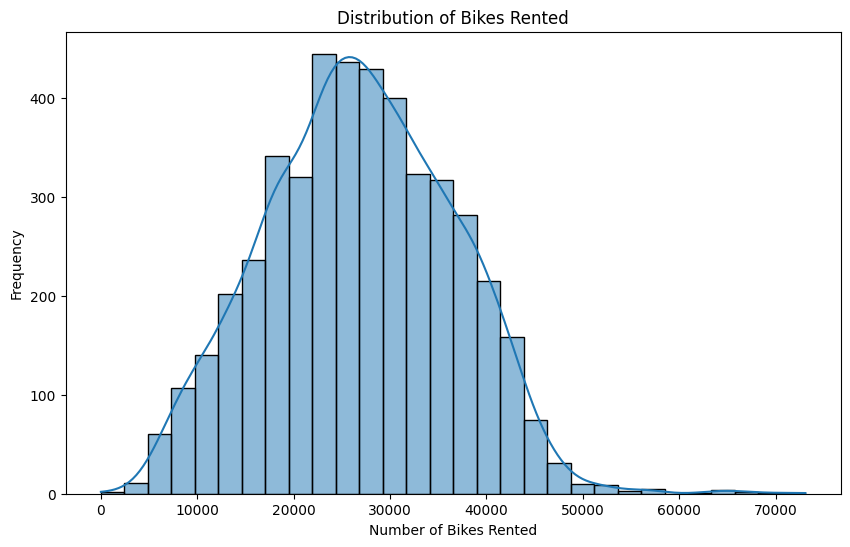

In [19]:
# Plot the distribution of bikes rented (bikes_hired)
plt.figure(figsize=(10, 6))
sns.histplot(bikes['bikes_hired'], bins=30, kde=True)
plt.title('Distribution of Bikes Rented')
plt.xlabel('Number of Bikes Rented')
plt.ylabel('Frequency')
plt.show()

A/ Interpretation:

The graph shows the distribution of bikes rented with X-axis representing the number of bikes rented and y-axis showing the frequency of the number of bikes rented. 
From the graph we can understand the following:

- ⁠Majority of bike rentals is between 20,000 and 30,000;
- ⁠Distribution is close to normal, most days have rentals near the average;
- It is unusual to have very high or very low number of rentals.

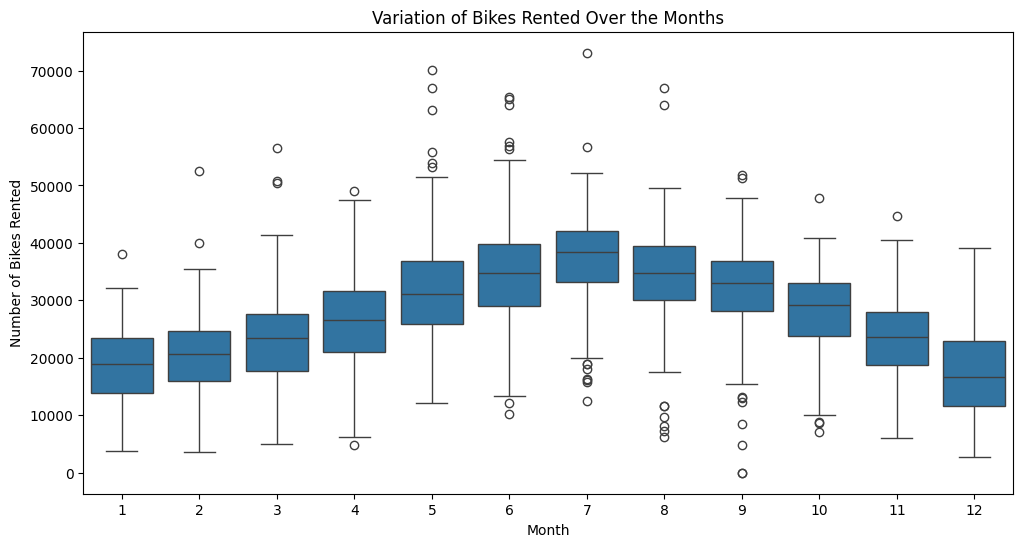

In [20]:
# Order the months correctly
bikes['month'] = pd.Categorical(bikes['month'], categories=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], ordered=True)
# Order the seasons correctly
bikes['season'] = pd.Categorical(bikes['season'], categories=['Winter', 'Spring', 'Summer', 'Fall'], ordered=True)
# Order the days of the week correctly
bikes['day_of_week'] = pd.Categorical(bikes['day_of_week'], categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], ordered=True)

# Variation of bikes rented over the months
plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='bikes_hired', data=bikes)
plt.title('Variation of Bikes Rented Over the Months')
plt.xlabel('Month')
plt.ylabel('Number of Bikes Rented')
plt.show()

A/ This graph is a boxplot showing how the number of bikes rented changes across the 12 months of the year. X-axis represents the months and Y-axis represents the number of bikes rented. From the graph:

- ⁠Rentals are lowest in the winter months and starts increasing starting from winter to spring (warmer time of the year);
- ⁠After July the rentals start decreasing;
- July has the highest number of rentals, meanwhile December has the lowest. However, rentals during winter months are more consistent than in summer.

/tmp/ipykernel_2515/241104915.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='season', y='bikes_hired', data=bikes, palette='Set2')


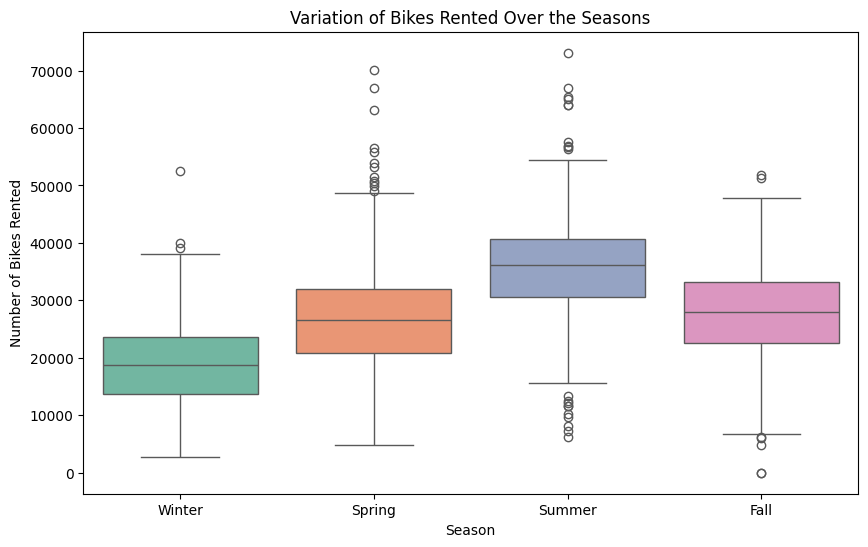

In [21]:
# Variation of bikes rented over the seasons
plt.figure(figsize=(10, 6))
sns.boxplot(x='season', y='bikes_hired', data=bikes, palette='Set2')
plt.title('Variation of Bikes Rented Over the Seasons')
plt.xlabel('Season')
plt.ylabel('Number of Bikes Rented')
plt.show()  

A/
Similarly to the previous plot, on this graph bike rentals are represented on the Y-axis, but this time instead of month, there are seasons on the X-axis: Winter, Spring, Summer and Fall.

From this graph we can make similar conclusions to the ones made from the previous boxplot graph with months:

- Summer has the highest number of rentals, then follows spring, then autumn and then winter;
- ⁠In summer the median of bikes rented is close to 40000, in winter: almost 20000.

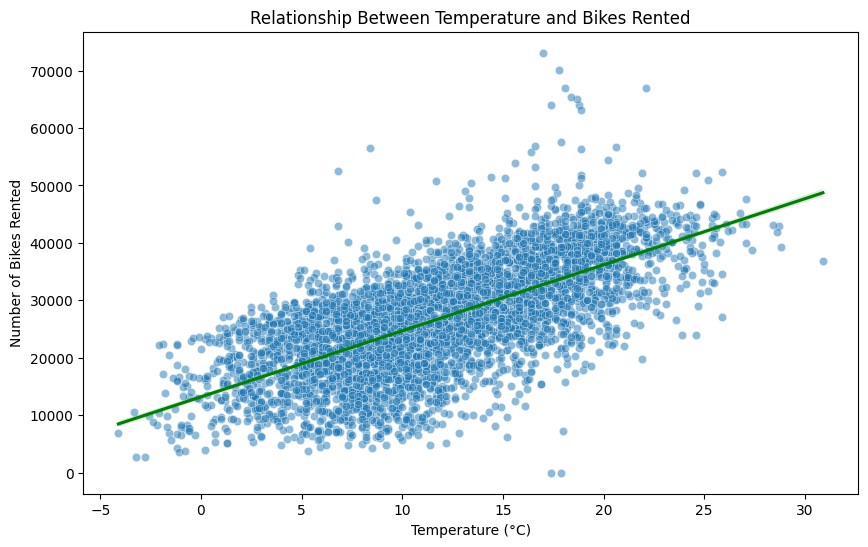

In [22]:
# Relaton between temperature and bikes rented with linear trend line
plt.figure(figsize=(10, 6))
sns.scatterplot(x='mean_temp', y='bikes_hired', data=bikes, alpha=0.5)
sns.regplot(x='mean_temp', y='bikes_hired', data=bikes, scatter=False, color='green')
plt.title('Relationship Between Temperature and Bikes Rented')
plt.xlabel('Temperature (°C)')
plt.ylabel('Number of Bikes Rented')
plt.show()

A/ This graph shows the relationship between the temperature and the amount of bikes rented. Since each dot represents each day on which the particular temperature and number of bikes rented were registered, we have made the following conclusions:

- The bike rentals are lowest when temperature is the lowest;
- ⁠With the increase of temperature, the amount of bikes rented generally increases, suggesting a positive correlation between the temperature and the amount of bikes rented. The warmer the weather, the more comfortable it is for cycling.

**3. Construct 95% confidence intervals for the mean number of bikes rented per season.**

Repeat the calculation per month.

Interpret the result:

What range of values do you expect the true mean to lie in?

Which seasons/months have higher or lower average demand?

Are there overlaps in the intervals, and what does that mean?

**Deliverables:**

A table or plot showing the mean and confidence intervals.

A short interpretation.

Confidence intervals: [26571.29, 27135.98]


/tmp/ipykernel_2515/3213609988.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = data.groupby('season')['bikes_hired'].mean()
/tmp/ipykernel_2515/3213609988.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stds = data.groupby('season')['bikes_hired'].std()
/tmp/ipykernel_2515/3213609988.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = data.groupby('season')['bikes_hired'].count()


,Mean,Lower Bound,Upper Bound
season,,,
Winter,18599.806885,18221.004356,18978.609414
Spring,26739.635088,26229.810621,27249.459554
Summer,35338.328638,34874.689160,35801.968117
Fall,27640.753833,27197.781690,28083.725976


/tmp/ipykernel_2515/3213609988.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = data.groupby('month')['bikes_hired'].mean()
/tmp/ipykernel_2515/3213609988.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stds = data.groupby('month')['bikes_hired'].std()
/tmp/ipykernel_2515/3213609988.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = data.groupby('month')['bikes_hired'].count()


,Mean,Lower Bound,Upper Bound
month,,,
1,18647.012658,18047.721062,19246.304254
2,20335.369146,19661.207247,21009.531045
3,22837.260652,22075.765897,23598.755407
4,26399.601078,25594.792376,27204.409780
5,31288.824324,30417.826408,32159.822240
6,34674.197183,33825.384699,35523.009668
7,37254.120944,36511.047191,37997.194697
8,34223.269542,33447.451315,34999.087768
9,32238.887640,31470.901875,33006.873406


/tmp/ipykernel_2515/3213609988.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = data.groupby('season')['bikes_hired'].mean()
/tmp/ipykernel_2515/3213609988.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stds = data.groupby('season')['bikes_hired'].std()
/tmp/ipykernel_2515/3213609988.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = data.groupby('season')['bikes_hired'].count()
/tmp/ipykernel_

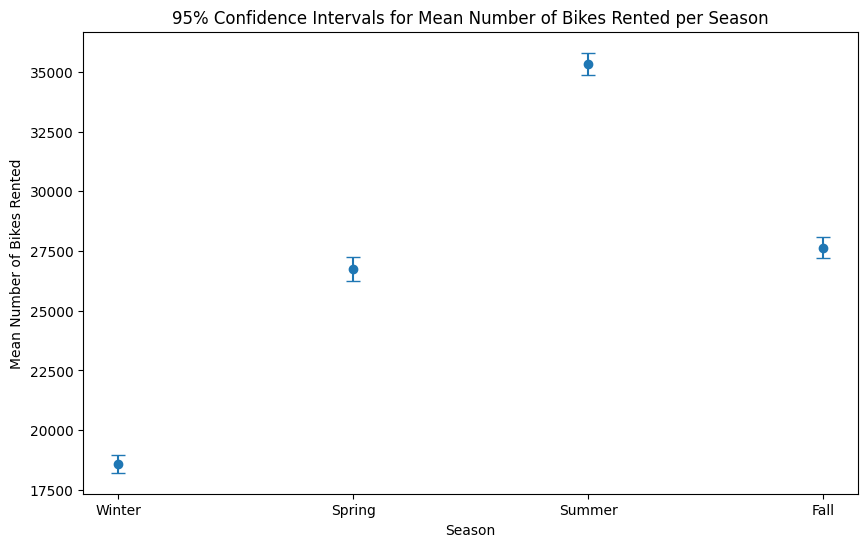

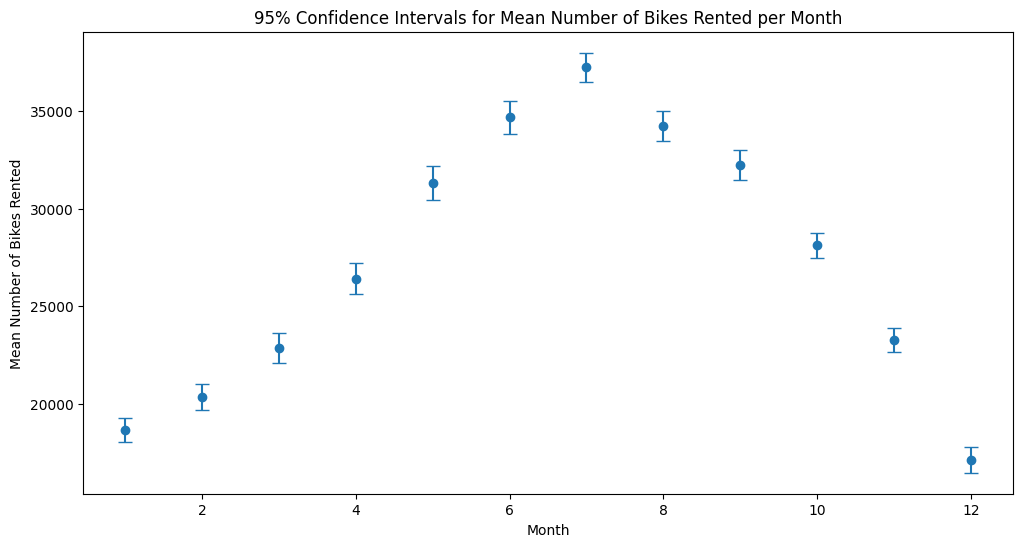

In [23]:
# Construct a 95% confidence interval for the mean number of bikes rented per season, display the results in a table
general_ci = stats.t.interval(confidence=0.95, df=len(bikes)-1, 
                      loc=np.mean(bikes.bikes_hired), scale=stats.sem(bikes.bikes_hired))
print(f'Confidence intervals: [{general_ci[0]:.2f}, {general_ci[1]:.2f}]')


def confidence_intervals(data, confidence=0.95):
    means = data.groupby('season')['bikes_hired'].mean()
    stds = data.groupby('season')['bikes_hired'].std()
    counts = data.groupby('season')['bikes_hired'].count()
    margins_of_error = stds / np.sqrt(counts) * 1.96  # for 95% confidence
    lower_bounds = means - margins_of_error
    upper_bounds = means + margins_of_error
    ci_df = pd.DataFrame({'Mean': means, 'Lower Bound': lower_bounds, 'Upper Bound': upper_bounds})
    return ci_df


display(confidence_intervals(bikes))

## Construct a 95% confidence interval for the mean number of bikes rented per month, display the results in a table
def confidence_intervals_month(data, confidence=0.95):
    means = data.groupby('month')['bikes_hired'].mean()
    stds = data.groupby('month')['bikes_hired'].std()
    counts = data.groupby('month')['bikes_hired'].count()
    margins_of_error = stds / np.sqrt(counts) * 1.96  # for 95% confidence
    lower_bounds = means - margins_of_error
    upper_bounds = means + margins_of_error
    ci_df = pd.DataFrame({'Mean': means, 'Lower Bound': lower_bounds, 'Upper Bound': upper_bounds})
    return ci_df
display(confidence_intervals_month(bikes))

#Plot the confidence intervals for the mean number of bikes rented per season and per month
ci_season = confidence_intervals(bikes)
ci_month = confidence_intervals_month(bikes)
# Plot for seasons
plt.figure(figsize=(10, 6))
plt.errorbar(ci_season.index, ci_season['Mean'], yerr=[ci_season['Mean'] - ci_season['Lower Bound'], ci_season['Upper Bound'] - ci_season['Mean']], fmt='o', capsize=5)
plt.title('95% Confidence Intervals for Mean Number of Bikes Rented per Season')
plt.xlabel('Season')
plt.ylabel('Mean Number of Bikes Rented')
plt.show()
# Plot for months
plt.figure(figsize=(12, 6))
plt.errorbar(ci_month.index, ci_month['Mean'], yerr=[ci_month['Mean'] - ci_month['Lower Bound'], ci_month['Upper Bound'] - ci_month['Mean']], fmt='o', capsize=5)
plt.title('95% Confidence Intervals for Mean Number of Bikes Rented per Month')
plt.xlabel('Month')
plt.ylabel('Mean Number of Bikes Rented')
plt.show()

A/ 
The true mean is expected to lie within the confidence intervals of 26571.29 and 27135.98.
We can say this with 95% confidence.

The average amount of bikes rented seems to rise over the hotter months of the year, then drops as the weather gets colder.

There seem to be overlaps between the followig months.
- Nov and Mar
- ⁠Oct and Apr
- Sep, Aug and May
- Jul and Jun

Overlapping months mean that the difference between them is not neccesarily accurrate, as it could be a result randomness.


**Regression Analysis**

What variables influence the number of bikes rented (y) and how? Build a regression model that best explains the variability in bikes rented.

**Interpret:**

Which predictors are significant?

What do the coefficients mean (in practical terms)?

How much of the variation in bike rentals is explained (R²)?

**Deliverables:**

Regression output table.

A short discussion of which factors matter most for predicting bike rentals.

In [24]:
# Regression Analysis
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf
model = smf.ols(
    formula="bikes_hired ~ mean_temp + humidity + radiation + precipitation + cloud_cover + C(season)",
    data=bikes
).fit()

print(model.summary()) 

                            OLS Regression Results                            
Dep. Variable:            bikes_hired   R-squared:                       0.601
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     860.3
Date:                Mon, 22 Sep 2025   Prob (F-statistic):               0.00
Time:                        20:33:51   Log-Likelihood:                -46351.
No. Observations:                4570   AIC:                         9.272e+04
Df Residuals:                    4561   BIC:                         9.278e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            2.522e+04   1

A/ )
Which predictors are significant?
1. The significant predictors are mean temperature, humidity, radiation, precipitation, and cloud cover. 
Summer and fall seasons are also significant, while spring is not significantly different from winter.
2. What do the coefficients mean in practical terms?
Warmer temperatures, higher radiation, and being in summer or fall are associated with more bike rentals. 
On the other hand, more humidity, precipitation, and cloud cover reduce rentals. For instance, an extra degree 
in temperature increases rentals by about 650, while each unit of precipitation lowers them by about 38.
3. How much of the variation in bike rentals is explained (R²)?
The model explains around 60% of the variation in bike rentals (R² = 0.601). This shows that weather and seasonal 
effects account for much of the demand, but a considerable part (about 40%) is still left unexplained.



Temperature and seasonal effects (summer and fall) are the strongest positive drivers of bike rentals. In contrast, precipitation and high humidity are major negative influences. This suggests that both pleasant weather conditions and broader seasonal patterns are the most important factors for predicting demand.

## Deliverables
A knitted HTML, one person per group to submit